In [2]:
import pandas as pd
import numpy as np

# Load training and testing sets
df1 = pd.read_csv('dataset/Training and Testing Sets/UNSW_NB15_training-set.csv')
df2 = pd.read_csv('dataset/Training and Testing Sets/UNSW_NB15_testing-set.csv')

# Combine both
df = pd.concat([df1, df2], ignore_index=True)

print("✅ Dataset loaded!")
print("Shape:", df.shape)
print("\nAttack types:\n", df['attack_cat'].value_counts())

✅ Dataset loaded!
Shape: (257673, 45)

Attack types:
 attack_cat
Normal            93000
Generic           58871
Exploits          44525
Fuzzers           24246
DoS               16353
Reconnaissance    13987
Analysis           2677
Backdoor           2329
Shellcode          1511
Worms               174
Name: count, dtype: int64


In [3]:
# Check missing values
print("Missing values before:", df.isnull().sum().sum())

# Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop null rows
df.dropna(inplace=True)

# Drop duplicates
df.drop_duplicates(inplace=True)

# Drop unnecessary columns
df.drop(['id'], axis=1, inplace=True, errors='ignore')

print("✅ Cleaning done!")
print("Shape after cleaning:", df.shape)

Missing values before: 0
✅ Cleaning done!
Shape after cleaning: (257673, 44)


In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode text columns
cat_cols = ['proto', 'service', 'state', 'attack_cat']
for col in cat_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))

print("✅ Encoding done!")
print(df.dtypes)

✅ Encoding done!
dur                  float64
proto                  int64
service                int64
state                  int64
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss                  int64
sinpkt               float64
dinpkt               float64
sjit                 float64
djit                 float64
swin                   int64
stcpb                  int64
dtcpb                  int64
dwin                   int64
tcprtt               float64
synack               float64
ackdat               float64
smean                  int64
dmean                  int64
trans_depth            int64
response_body_len      int64
ct_srv_src             int64
ct_state_ttl           int64
ct_dst_ltm             int64
ct_src_dport_ltm       int

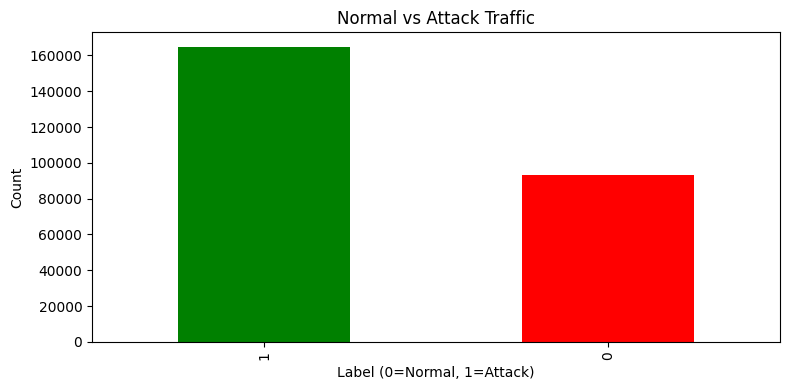


Label counts:
 label
1    164673
0     93000
Name: count, dtype: int64


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
df['label'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Normal vs Attack Traffic')
plt.xlabel('Label (0=Normal, 1=Attack)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print("\nLabel counts:\n", df['label'].value_counts())

In [7]:
df.to_csv('dataset/cleaned_data.csv', index=False)
print("✅ Saved to cleaned_data.csv!")
print("Final shape:", df.shape)

✅ Saved to cleaned_data.csv!
Final shape: (257673, 44)
